# Phase 1 — Data Preparation & Time-Integrated Transport Matrix

**Goal**: Instead of picking ONE timestamp (as in notebook 1), we:
1. Load all 14 stations × all timestamps
2. Build T(t) for every timestamp — a 3-D tensor
3. Quality-filter, flag bad windows
4. Export clean arrays ready for Phase 2 (fingerprinting) and Phase 3 (Bayesian)

**Why this matters**: In notebook 1 you solved `C = T·Q` at a single moment.
That is like judging a river's flow by looking at it once.
With T(t) we capture how transport changes with wind — day/night, season, weather.

```
Shape summary
  df_pivot   : (n_times, 14)      — pollutant concentration matrix
  T_tensor   : (n_times, 14, 14)  — T[t, i, j] = how much station-j affects station-i at time t
  meta_df    : (n_times, 14*4)    — WS, WD, SR, stability class per station per time
```

## Block 0 — Imports & Path Setup

In [ ]:
# import matplotlib.pyplot as plt
# import scienceplots
# plt.style.use(['science','no-latex'])

In [ ]:
#  Standard library
import sys
import logging
from pathlib import Path

#  Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

#  Make the local helper module importable (same trick as notebook 1)
NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

#  Logging setup — gives timestamped messages instead of bare prints
# This is critical for long loops: you'll see progress + errors in one stream.
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("phase1")

10:52:04  INFO      Imports OK


In [2]:
# Import from transport_matrix.py (your existing helper)
from transport_matrix import (
    build_transport_matrix,
    stability_class,
    haversine_km,
    bearing_deg,
)

## Block 1 — Configuration (edit here, nowhere else)

In [ ]:
POLLUTANT = "pm25"  # Which column to treat as 'concentration C'
H_STACK = 20.0  # Effective emission height [m] — same as notebook 1
MIN_STATIONS = 10  # Minimum number of stations that must have valid data
# at a given timestamp to keep that row. < 10 → too sparse.

# Quality thresholds — values outside these are flagged as suspect
# (set to None to disable a check)
QC = dict(
    pm25_min=0.0,  # Concentration cannot be negative
    pm25_max=999.0,  # 999 µg/m³ is already extreme; higher = instrument error
    ws_min=0.0,  # Wind speed cannot be negative
    ws_max=30.0,  # 30 m/s in Bangalore = anemometer spike
    wd_min=0.0,  # Wind direction 0–360°
    wd_max=360.0,
)

#  File paths — adjust to your project layout
ROOT_DIR = Path().resolve().parents[2]
DATA_DIR = ROOT_DIR / "backend" / "data"
MASTER_DATASET_FILE = DATA_DIR / "artifacts" / "final_master_dataset.csv"
STATIONS_FILE = DATA_DIR / "raw" / "stations.csv"

#  Output directory for artefacts produced by this notebook
OUT_DIR = NOTEBOOK_DIR / "data_prep"
OUT_DIR.mkdir(exist_ok=True)

log.info(f"Pollutant      : {POLLUTANT}")
log.info(f"Stack height   : {H_STACK} m")
log.info(f"Min stations   : {MIN_STATIONS}")
log.info(f"Output dir     : {OUT_DIR}")

10:54:35  INFO      Pollutant      : pm25
10:54:35  INFO      Stack height   : 20.0 m
10:54:35  INFO      Min stations   : 10
10:54:35  INFO      Output dir     : /home/srirama/Documents/sr_proj/AirModeling/backend/tests/notebooks/chemical_fingerprinting


## Block 2 — Load Station Metadata

In [5]:
# Load station lat/lon — same stations.csv you already use
stations_df = pd.read_csv(STATIONS_FILE)
STATION_NAMES = stations_df["station_name"].tolist()   # preserves order
N = len(STATION_NAMES)

# Numpy arrays for vectorised distance/bearing calculations
LATS = stations_df["latitude"].values
LONS = stations_df["longitude"].values

log.info(f"Loaded {N} stations")
display(stations_df)

10:54:40  INFO      Loaded 14 stations


,slNo,station_name,organization,latitude,longitude,site_id
0,1,BTMLayout,CPCB,12.9135,77.5951,162
1,2,BWSSBKadabesanahalli,CPCB,12.9352,77.6814,164
2,3,BapujiNagar,KSPCB,12.9519,77.5398,1553
3,4,CityRailwayStation,KSPCB,12.9757,77.5661,165
4,5,Hebbal,KSPCB,13.0292,77.5859,1554
5,6,HombegowdaNagar,KSPCB,12.9385,77.5901,1555
6,7,Jayanagar5thBlock,KSPCB,12.9210,77.5849,1556
7,8,Jigani,KSPCB,12.7816,77.6299,5729
8,9,KasturiNagar,KSPCB,13.0039,77.6642,5681
9,10,Peenya,CPCB,13.0270,77.4941,163


## Block 3 — Load Raw Data & Initial Quality Control

We apply a two-pass QC:
- **Pass 1 (value QC)**: Replace physically impossible values with NaN
- **Pass 2 (coverage QC)**: Drop timestamps where fewer than `MIN_STATIONS` have valid data

In [6]:
log.info("Loading master dataset…")
df_raw = pd.read_csv(MASTER_DATASET_FILE, parse_dates=["time"])

# Keep only our 14 stations
df_raw = df_raw[df_raw["station_name"].isin(STATION_NAMES)].copy()
log.info(f"Raw rows after station filter: {len(df_raw):,}")


#  Pass 1: Value QC — replace out-of-range with NaN
# We do this on the long-format table, column by column.
# 'clip' would silently distort data; setting to NaN is honest.
def qc_range(series, low, high, label):
    """Set values outside [low, high] to NaN and report how many."""
    mask = (series < low) | (series > high)
    n_bad = mask.sum()
    if n_bad > 0:
        log.warning(f"  QC [{label}]: {n_bad:,} values outside [{low}, {high}] → NaN")
    return series.where(~mask, other=np.nan)


df_raw[POLLUTANT] = qc_range(
    df_raw[POLLUTANT], QC["pm25_min"], QC["pm25_max"], POLLUTANT
)
df_raw["wind_speed"] = qc_range(
    df_raw["wind_speed"], QC["ws_min"], QC["ws_max"], "wind_speed"
)
df_raw["wind_direction"] = qc_range(
    df_raw["wind_direction"], QC["wd_min"], QC["wd_max"], "wind_direction"
)

log.info("Pass 1 QC complete")
display(
    df_raw[
        [
            "time",
            "station_name",
            POLLUTANT,
            "wind_speed",
            "wind_direction",
            "solar_radiation",
        ]
    ].head(8)
)

10:55:31  INFO      Loading master dataset…
10:55:34  INFO      Raw rows after station filter: 420,480
10:55:34  INFO      Pass 1 QC complete


,time,station_name,pm25,wind_speed,wind_direction,solar_radiation
0,2025-01-01 00:00:00,BapujiNagar,36.0000,0.0000,114.0000,0.0000
1,2025-01-01 00:15:00,BapujiNagar,36.0000,0.0000,112.0000,0.0000
2,2025-01-01 00:30:00,BapujiNagar,36.0000,0.0000,117.0000,0.0000
3,2025-01-01 00:45:00,BapujiNagar,47.0000,0.0000,112.0000,0.0000
4,2025-01-01 01:00:00,BapujiNagar,47.0000,0.0000,118.0000,0.0000
5,2025-01-01 01:15:00,BapujiNagar,47.0000,0.0000,105.0000,0.0000
6,2025-01-01 01:30:00,BapujiNagar,47.0000,0.0000,107.0000,0.0000
7,2025-01-01 01:45:00,BapujiNagar,47.0000,0.0000,101.0000,0.0000


## Block 4 — Pivot to Wide Format & Coverage QC

In [ ]:
#  Pivot each variable: rows=time, columns=station_name
# We need 4 pivot tables: C, WS, WD, SR
def pivot_var(df, var):
    """Pivot a single variable from long to wide (time × station)."""
    return (
        df.pivot_table(
            index="time", columns="station_name", values=var, aggfunc="first"
        ).reindex(columns=STATION_NAMES)  # keep consistent column order
    )

C_wide = pivot_var(df_raw, POLLUTANT)  # (n_times, 14) — concentration
WS_wide = pivot_var(df_raw, "wind_speed")  # (n_times, 14) — wind speed
WD_wide = pivot_var(df_raw, "wind_direction")  # (n_times, 14) — wind direction
SR_wide = pivot_var(df_raw, "solar_radiation")  # (n_times, 14) — solar radiation

log.info(f"Pivot shape: {C_wide.shape}  (timestamps × stations)")
print("Sample pivot (concentration C):")
display(C_wide.head())
print("Sample pivot (wind speed WS):")
display(WS_wide.head())
print("Sample pivot (wind direction WD):")
display(WD_wide.head())
print("Sample pivot (solar radiation SR):")
display(SR_wide.head())

10:57:52  INFO      Pivot shape: (35040, 14)  (timestamps × stations)


Sample pivot (concentration C):


station_name,BTMLayout,BWSSBKadabesanahalli,BapujiNagar,CityRailwayStation,Hebbal,HombegowdaNagar,Jayanagar5thBlock,Jigani,KasturiNagar,Peenya,RvceMailasandra,SaneguravaHalli,ShivapuraPeenya,SilkBoard
time,,,,,,,,,,,,,,
2025-01-01 00:00:00,NaN,NaN,36.0000,0.0000,62.0000,61.0000,65.0000,71.1600,32.9900,47.9200,1.0500,0.0000,29.0000,57.0000
2025-01-01 00:15:00,NaN,NaN,36.0000,0.0000,62.0000,61.0000,65.0000,71.1600,32.9900,47.9200,1.0500,0.0000,29.0000,57.0000
2025-01-01 00:30:00,NaN,NaN,36.0000,0.0000,62.0000,61.0000,65.0000,71.1600,32.9900,47.9200,0.9900,0.0000,29.0000,57.0000
2025-01-01 00:45:00,NaN,NaN,47.0000,0.0000,87.0000,64.4000,92.0000,87.4300,33.0100,48.2100,0.9600,0.0000,29.0000,68.0000
2025-01-01 01:00:00,NaN,NaN,47.0000,0.0000,87.0000,67.8000,92.0000,89.0100,33.1000,48.7900,0.9600,0.0000,28.8900,68.0000


Sample pivot (wind speed WS):


station_name,BTMLayout,BWSSBKadabesanahalli,BapujiNagar,CityRailwayStation,Hebbal,HombegowdaNagar,Jayanagar5thBlock,Jigani,KasturiNagar,Peenya,RvceMailasandra,SaneguravaHalli,ShivapuraPeenya,SilkBoard
time,,,,,,,,,,,,,,
2025-01-01 00:00:00,NaN,NaN,0.0000,0.0000,0.5000,0.0000,0.0000,5.5000,1.5700,0.0000,2.3100,0.0296,0.4600,0.8000
2025-01-01 00:15:00,NaN,NaN,0.0000,0.0000,0.6000,0.0000,0.0000,5.8700,1.5600,0.0000,2.7100,0.0296,0.4600,1.2000
2025-01-01 00:30:00,NaN,NaN,0.0000,0.0000,0.5000,0.0000,0.0000,5.5100,1.4800,0.0000,2.4100,0.0296,0.4600,1.0000
2025-01-01 00:45:00,NaN,NaN,0.0000,0.0000,0.5000,0.0000,0.0000,5.5000,1.5000,0.0000,2.4400,0.0296,0.4600,1.3000
2025-01-01 01:00:00,NaN,NaN,0.0000,0.0000,0.5000,0.0000,0.0000,5.2000,1.4100,0.0000,2.4500,0.0294,0.4100,1.1000


Sample pivot (wind direction WD):


station_name,BTMLayout,BWSSBKadabesanahalli,BapujiNagar,CityRailwayStation,Hebbal,HombegowdaNagar,Jayanagar5thBlock,Jigani,KasturiNagar,Peenya,RvceMailasandra,SaneguravaHalli,ShivapuraPeenya,SilkBoard
time,,,,,,,,,,,,,,
2025-01-01 00:00:00,NaN,NaN,114.0000,NaN,97.0000,197.0000,156.0000,114.6100,42.4900,NaN,254.7200,NaN,78.1700,125.0000
2025-01-01 00:15:00,NaN,NaN,112.0000,NaN,97.0000,216.0000,152.0000,114.6300,40.1400,NaN,243.5200,NaN,78.1700,87.0000
2025-01-01 00:30:00,NaN,NaN,117.0000,NaN,97.0000,214.0000,201.0000,111.3000,45.0000,NaN,251.7300,NaN,78.1700,100.0000
2025-01-01 00:45:00,NaN,NaN,112.0000,NaN,97.0000,211.0000,156.0000,110.8400,42.0700,NaN,242.1600,NaN,78.1700,78.0000
2025-01-01 01:00:00,NaN,NaN,118.0000,NaN,97.0000,217.0000,133.0000,118.4600,46.3800,NaN,267.1400,NaN,78.1700,82.0000


Sample pivot (solar radiation SR):


station_name,BTMLayout,BWSSBKadabesanahalli,BapujiNagar,CityRailwayStation,Hebbal,HombegowdaNagar,Jayanagar5thBlock,Jigani,KasturiNagar,Peenya,RvceMailasandra,SaneguravaHalli,ShivapuraPeenya,SilkBoard
time,,,,,,,,,,,,,,
2025-01-01 00:00:00,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,6.4300,10.4800,5.5900,0.0000,1.7700,0.0000,0.0000
2025-01-01 00:15:00,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,6.4800,10.6200,5.5900,0.0000,1.5000,0.0000,0.0000
2025-01-01 00:30:00,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,6.5800,10.1900,5.5900,0.0000,2.5000,0.0000,0.0000
2025-01-01 00:45:00,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,6.4400,10.1700,5.5900,0.0000,4.9500,0.0000,0.0000
2025-01-01 01:00:00,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,6.5900,10.3300,5.5900,0.0000,2.6700,0.0000,0.0000


In [14]:
display(C_wide.isna().sum(axis=0)) , display(C_wide.isna().sum(axis=1))

station_name
BTMLayout               35040
BWSSBKadabesanahalli    35040
BapujiNagar                 0
CityRailwayStation          0
Hebbal                      0
HombegowdaNagar             0
Jayanagar5thBlock           0
Jigani                      0
KasturiNagar                0
Peenya                      0
RvceMailasandra             0
SaneguravaHalli             0
ShivapuraPeenya             0
SilkBoard                   0
dtype: int64

time
2025-01-01 00:00:00    2
2025-01-01 00:15:00    2
2025-01-01 00:30:00    2
2025-01-01 00:45:00    2
2025-01-01 01:00:00    2
                      ..
2025-12-31 22:45:00    2
2025-12-31 23:00:00    2
2025-12-31 23:15:00    2
2025-12-31 23:30:00    2
2025-12-31 23:45:00    2
Length: 35040, dtype: int64

(None, None)

11:11:14  INFO      Timestamps before coverage filter : 35,040
11:11:14  INFO      Timestamps after  coverage filter : 35,040  (≥10 stations)
/tmp/ipykernel_15079/4019021364.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(STATION_NAMES, rotation=45, ha="right", fontsize=8)


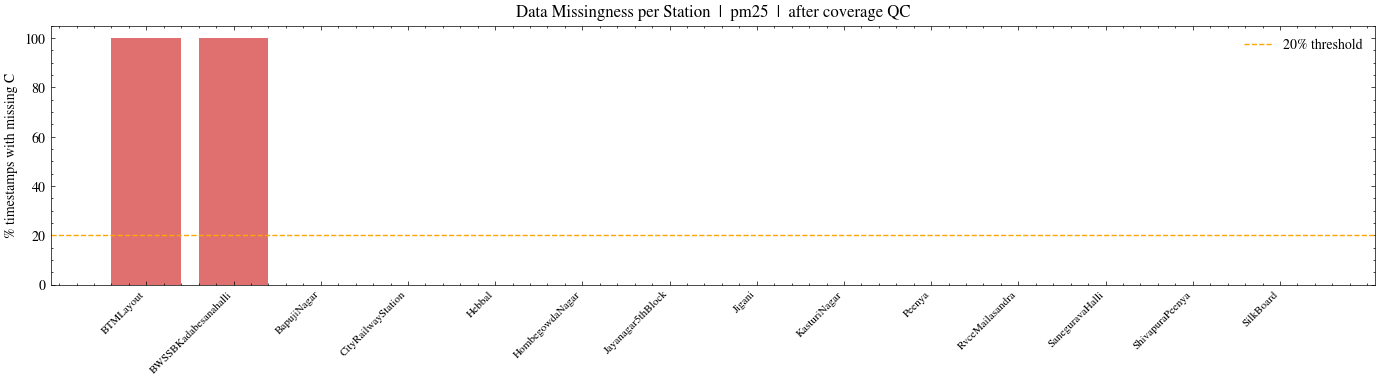

11:11:15  INFO      Saved: fig_missingness.png


In [22]:
#  Pass 2: Coverage QC — keep only times with enough stations
# C_wide.notna().sum(axis=1) = number of stations with valid concentration at each time
station_count = C_wide.notna().sum(axis=1)  # Series indexed by time
valid_times = station_count[station_count >= MIN_STATIONS].index

log.info(f"Timestamps before coverage filter : {len(C_wide):,}")
log.info(
    f"Timestamps after  coverage filter : {len(valid_times):,}  (≥{MIN_STATIONS} stations)"
)

# Apply filter to all 4 wide tables
C_wide = C_wide.loc[valid_times]
WS_wide = WS_wide.loc[valid_times]
WD_wide = WD_wide.loc[valid_times]
SR_wide = SR_wide.loc[valid_times]

#  Visualise missingness after QC
fig, ax = plt.subplots(figsize=(14, 4))
miss_pct = C_wide.isna().mean() * 100  # % missing per station
ax.bar(STATION_NAMES, miss_pct, color="#e07070")
ax.set_xticklabels(STATION_NAMES, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("% timestamps with missing C")
ax.set_title(f"Data Missingness per Station  |  {POLLUTANT}  |  after coverage QC")
ax.axhline(20, color="orange", lw=1, ls="--", label="20% threshold")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_missingness.png", dpi=150, bbox_inches="tight")
plt.show()
log.info("Saved: fig_missingness.png")

## Block 5 — Imputation Strategy

We use **forward-fill then backward-fill** (time-aware) rather than global median.

**Why?**  
- Air quality is autocorrelated in time (t+1 is close to t).  
- Global median ignores the time structure entirely.  
- We only fill remaining NaNs (after ff/bf) with the station-specific median as a last resort.

Wind direction needs special treatment: it wraps at 360°, so you cannot simply average 350° and 10° — you'd get 180°. We use circular mean.

In [17]:
def fill_timeseries(wide_df, label, circular=False):
    """
    Impute a wide (time × station) DataFrame.
    Strategy:
      1. Forward-fill up to 2 steps (30 min gap at 15-min data)
      2. Backward-fill up to 2 steps
      3. Station-median for anything still missing
    If circular=True (wind direction), we work in sin/cos space.
    """
    if circular:
        # Convert to unit-vector components, interpolate, convert back
        rad = np.deg2rad(wide_df.values.astype(float))
        s = pd.DataFrame(np.sin(rad), index=wide_df.index, columns=wide_df.columns)
        c = pd.DataFrame(np.cos(rad), index=wide_df.index, columns=wide_df.columns)
        s = s.ffill(limit=2).bfill(limit=2).fillna(s.median())
        c = c.ffill(limit=2).bfill(limit=2).fillna(c.median())
        deg = np.degrees(np.arctan2(s.values, c.values)) % 360
        result = pd.DataFrame(deg, index=wide_df.index, columns=wide_df.columns)
    else:
        result = (
            wide_df
            .ffill(limit=2)
            .bfill(limit=2)
            .fillna(wide_df.median())     # station-specific fallback
        )

    remaining_nan = result.isna().sum().sum()
    if remaining_nan > 0:
        log.warning(f"  [{label}] Still {remaining_nan} NaNs after imputation — filling global median")
        result = result.fillna(result.stack().median())
    log.info(f"  [{label}] Imputation complete — 0 NaNs remaining")
    return result

log.info("Imputing missing values…")
C_filled  = fill_timeseries(C_wide,  "C (concentration)",    circular=False)
WS_filled = fill_timeseries(WS_wide, "WS (wind speed)",       circular=False)
WD_filled = fill_timeseries(WD_wide, "WD (wind direction)",   circular=True)   # wrap-safe
SR_filled = fill_timeseries(SR_wide, "SR (solar radiation)",  circular=False)

log.info(f"Final dataset shape: {C_filled.shape}  → {C_filled.shape[0]} timestamps, {N} stations")

11:07:48  INFO      Imputing missing values…
11:07:48  WARNING     [C (concentration)] Still 70080 NaNs after imputation — filling global median
11:07:48  INFO        [C (concentration)] Imputation complete — 0 NaNs remaining
11:07:48  WARNING     [WS (wind speed)] Still 70080 NaNs after imputation — filling global median
11:07:48  INFO        [WS (wind speed)] Imputation complete — 0 NaNs remaining
11:07:48  WARNING     [WD (wind direction)] Still 175200 NaNs after imputation — filling global median
11:07:48  INFO        [WD (wind direction)] Imputation complete — 0 NaNs remaining
11:07:48  WARNING     [SR (solar radiation)] Still 70080 NaNs after imputation — filling global median
11:07:49  INFO        [SR (solar radiation)] Imputation complete — 0 NaNs remaining
11:07:49  INFO      Final dataset shape: (35040, 14)  → 35040 timestamps, 14 stations


## Block 6 — Derive Stability Classes for Every (time, station)

Each station sees different wind conditions, so stability class is
station-specific at every timestamp. We build a `(n_times, N)` array.

In [18]:
from collections import Counter

# Time metadata needed for stability class
times = C_filled.index  # DatetimeIndex
hours = times.hour  # 0–23
is_daytime = (hours >= 6) & (hours < 18)  # crude day/night split

n_times = len(times)

# Stability class array: (n_times, N)
# stability_class() from transport_matrix.py returns a string 'A'..'F'
STAB_classes = np.empty((n_times, N), dtype=object)

for t_idx in range(n_times):
    for s_idx in range(N):
        STAB_classes[t_idx, s_idx] = stability_class(
            wind_speed_ms=WS_filled.iat[t_idx, s_idx],
            solar_rad_Wm2=SR_filled.iat[t_idx, s_idx],
            is_daytime=bool(is_daytime[t_idx]),
        )

# Sanity check — show distribution of stability classes
flat = STAB_classes.flatten()

counts = Counter(flat)
print("Stability class distribution (all stations, all times):")
for cls in ["A", "B", "C", "D", "E", "F"]:
    pct = counts.get(cls, 0) / len(flat) * 100
    bar = "█" * int(pct / 2)
    print(f"  {cls}: {bar:25s} {pct:5.1f}%")

Stability class distribution (all stations, all times):
  A:                             1.5%
  B: █                           2.8%
  C: ██████████████████████     45.1%
  D:                             1.7%
  E:                             0.8%
  F: ████████████████████████   48.1%


## Block 7 — Build T(t): The 3-D Transport Tensor

**What is the T tensor?**

```
T_tensor[t, i, j] = transport coefficient from source j to receptor i at time t
                   = (concentration at i) per unit emission at j
                     given wind conditions at time t
```

We call `build_transport_matrix()` from your existing helper for each timestamp.
This loop is the computational bottleneck; `tqdm` shows progress.

**Time estimate**: ~14×14 = 196 transport_element calls per timestamp.
At 15-min intervals, 1 year = 35,040 timestamps → ~6.8M calls.
Python loops: roughly 30–120 seconds on a laptop. We'll vectorise later if needed.

In [ ]:
# Pre-allocate: (n_times, N, N)  — float32 to save memory
# float32 is fine because transport coefficients span many decades anyway
T_tensor = np.zeros((n_times, N, N), dtype=np.float32)

log.info(f"Building T tensor: {n_times} timestamps × {N}×{N} matrix…")
log.info(f"Memory footprint: {T_tensor.nbytes / 1e6:.1f} MB")

for t_idx in tqdm(range(n_times), desc="Building T(t)", unit="ts"):
    T_tensor[t_idx] = build_transport_matrix(
        lats=LATS,
        lons=LONS,
        wind_speeds=WS_filled.iloc[t_idx].values,
        wind_directions=WD_filled.iloc[t_idx].values,
        stability_classes=STAB_classes[t_idx],
        stack_height=H_STACK,
    )

log.info("T tensor complete")
print(f"T_tensor shape : {T_tensor.shape}")
print(f"T non-zero vals: {(T_tensor > 0).sum():,}")
print(f"T max value    : {T_tensor.max():.4f}")
print(f"T mean non-zero: {T_tensor[T_tensor > 0].mean():.6f}")

11:08:52  INFO      Building T tensor: 35040 timestamps × 14×14 matrix…
11:08:52  INFO      Memory footprint: 27.5 MB
Building T(t): 100%|██████████| 35040/35040 [01:03<00:00, 554.16ts/s]
11:09:55  INFO      T tensor complete


T_tensor shape : (35040, 14, 14)
T non-zero vals: 1,342,823
T max value    : 432.3186
T mean non-zero: 1.616070


## Block 8 — Visualise the T Tensor: Mean Transport Map

We average T over time to see the *typical* influence pattern.
A heatmap where `T_mean[i, j]` is bright means station j is a
consistent contributor to station i's pollution.

/tmp/ipykernel_15079/1555269074.py:38: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) STIXGeneral.
  plt.tight_layout()
/tmp/ipykernel_15079/1555269074.py:39: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) STIXGeneral.
  plt.savefig(OUT_DIR / "fig_T_mean_heatmap.png", dpi=150, bbox_inches="tight")
/home/srirama/micromamba/envs/pytorch/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) STIXGeneral.
  fig.canvas.print_figure(bytes_io, **kw)


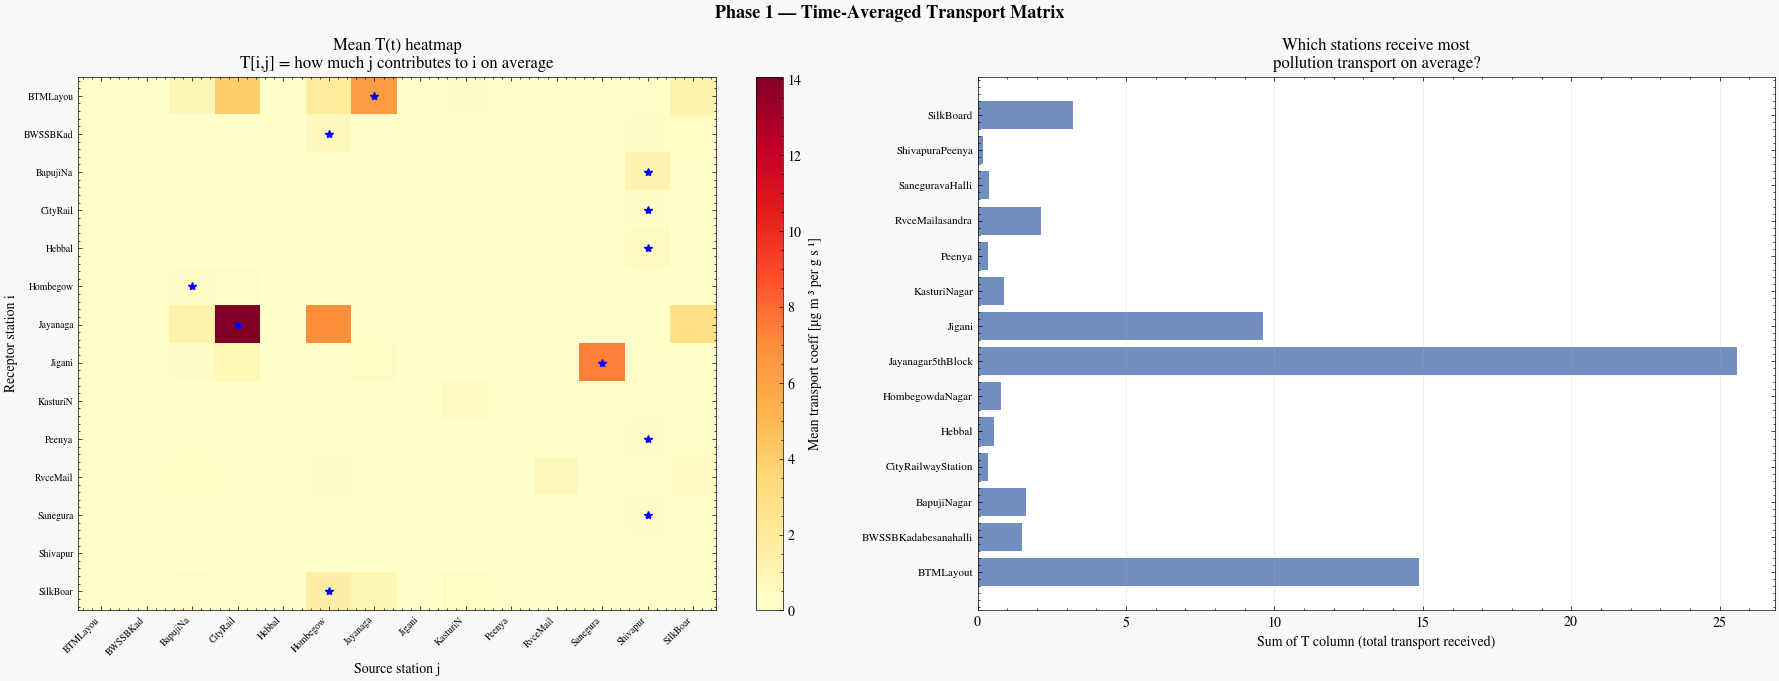

11:11:29  INFO      Saved: fig_T_mean_heatmap.png


In [23]:
# Time-average transport matrix
T_mean = T_tensor.mean(axis=0)  # (N, N)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#f8f8f8")

#  Left: Mean T heatmap
ax = axes[0]
im = ax.imshow(T_mean, cmap="YlOrRd", aspect="auto")
plt.colorbar(im, ax=ax, label="Mean transport coeff [µg m⁻³ per g s⁻¹]")
ax.set_xticks(range(N))
ax.set_yticks(range(N))
short_names = [s[:8] for s in STATION_NAMES]
ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(short_names, fontsize=7)
ax.set_xlabel("Source station j")
ax.set_ylabel("Receptor station i")
ax.set_title("Mean T(t) heatmap\nT[i,j] = how much j contributes to i on average")

# Annotate the max contributor for each receptor
for i in range(N):
    j_max = T_mean[i].argmax()
    if j_max != i:  # skip self-contribution
        ax.plot(j_max, i, "b*", ms=6)

#  Right: Total inflow per receptor (column sum)
ax2 = axes[1]
total_influence = T_mean.sum(axis=1)  # row sum: total T received at each receptor
y_pos = np.arange(N)
ax2.barh(y_pos, total_influence, color="#4C72B0", alpha=0.8)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(STATION_NAMES, fontsize=8)
ax2.set_xlabel("Sum of T column (total transport received)")
ax2.set_title("Which stations receive most\npollution transport on average?")
ax2.grid(axis="x", alpha=0.3)

plt.suptitle("Phase 1 — Time-Averaged Transport Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_T_mean_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
log.info("Saved: fig_T_mean_heatmap.png")

## Block 9 — Temporal Stability of T: Does Wind Pattern Change?

We compute the **coefficient of variation** (std/mean) of each T[i,j] over time.
High CV → the link between stations is highly variable (wind changes direction a lot).
Low CV → consistent transport pathway — reliable source-receptor pair.

/tmp/ipykernel_15079/4177232814.py:4: RuntimeWarning: invalid value encountered in divide
  T_cv  = np.where(T_mean > 1e-9, T_std / T_mean, np.nan)


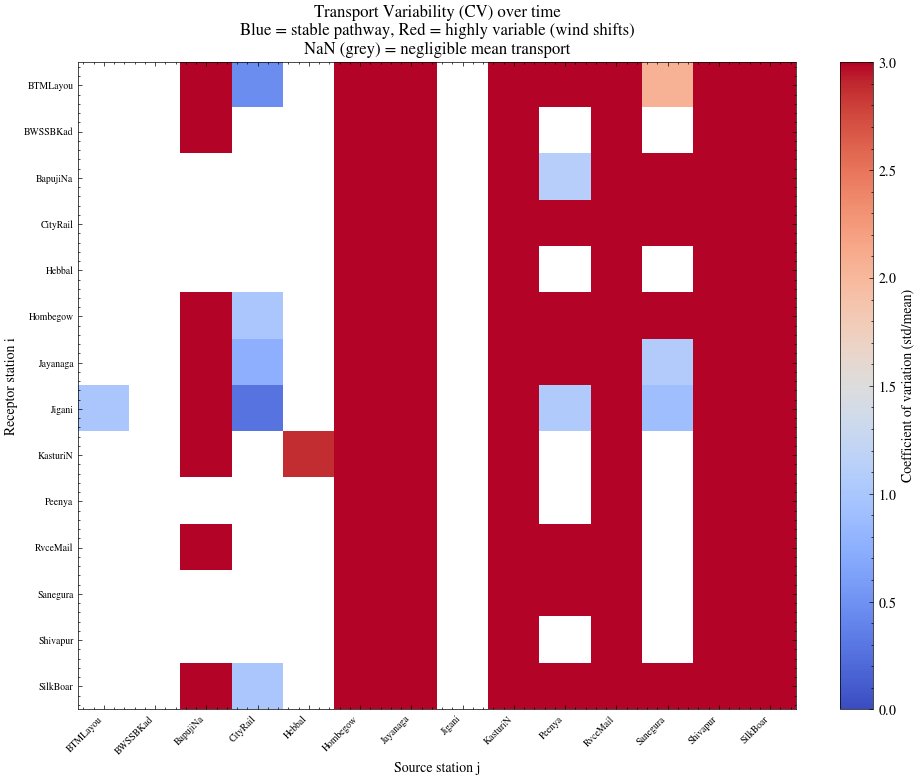

In [24]:
# CV = std / mean, per (i,j) pair, across time axis
T_std = T_tensor.std(axis=0)
# Avoid division by zero for pairs with near-zero mean transport
T_cv  = np.where(T_mean > 1e-9, T_std / T_mean, np.nan)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(T_cv, cmap="coolwarm", vmin=0, vmax=3, aspect="auto")
plt.colorbar(im, ax=ax, label="Coefficient of variation (std/mean)")
ax.set_xticks(range(N))
ax.set_yticks(range(N))
ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(short_names, fontsize=7)
ax.set_xlabel("Source station j")
ax.set_ylabel("Receptor station i")
ax.set_title(
    "Transport Variability (CV) over time\n"
    "Blue = stable pathway, Red = highly variable (wind shifts)\n"
    "NaN (grey) = negligible mean transport"
)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_T_variability.png", dpi=150, bbox_inches="tight")
plt.show()

## Block 10 — Export Artefacts for Downstream Notebooks

Phase 2 (fingerprinting) and Phase 3 (Bayesian) will load these directly.
We save:
- `T_tensor.npy`   — 3-D numpy array (n_times, N, N)
- `C_matrix.parquet` — wide concentration matrix (n_times, N)
- `WS_matrix.parquet`, `WD_matrix.parquet` — met data
- `meta.parquet`   — times, hours, is_daytime, stability classes

In [26]:
#  Save T tensor (numpy binary — fast, exact) 
np.save(OUT_DIR / "T_tensor.npy", T_tensor)
log.info(f"Saved T_tensor.npy  ({T_tensor.nbytes/1e6:.1f} MB)")

#  Save concentration and met matrices (parquet = fast + typed) 
C_filled.to_parquet(OUT_DIR  / "C_matrix.parquet")
WS_filled.to_parquet(OUT_DIR / "WS_matrix.parquet")
WD_filled.to_parquet(OUT_DIR / "WD_matrix.parquet")
SR_filled.to_parquet(OUT_DIR / "SR_matrix.parquet")

#  Save stability class array as a flat DataFrame 
stab_df = pd.DataFrame(
    STAB_classes,
    index   = times,
    columns = STATION_NAMES,
)
stab_df.to_parquet(OUT_DIR / "stability_classes.parquet")

#  Save a metadata summary 
meta_df = pd.DataFrame({
    "hour"       : hours,
    "is_daytime" : is_daytime,
    "n_valid_C"  : C_wide.loc[valid_times].notna().sum(axis=1).values,
}, index=times)
meta_df.to_parquet(OUT_DIR / "meta.parquet")


#  Final summary 
print("\n" + "="*60)
print("PHASE 1 SUMMARY")
print("="*60)
print(f"  Timestamps analysed      : {n_times:,}")
print(f"  Stations                 : {N}")
print(f"  Pollutant                : {POLLUTANT}")
print(f"  T tensor shape           : {T_tensor.shape}")
print(f"  T tensor memory          : {T_tensor.nbytes/1e6:.1f} MB")
print(f"  Date range               : {times[0].date()} → {times[-1].date()}")
print(f"  Dominant stability class : {Counter(STAB_classes.flatten()).most_common(1)[0]}")
print("="*60)
print("\nReady for:")
print("  → Phase 2: Chemical Fingerprinting  (2_fingerprinting.ipynb)")
print("  → Phase 3: Bayesian Inversion       (3_bayesian.ipynb)")

11:13:24  INFO      Saved T_tensor.npy  (27.5 MB)



PHASE 1 SUMMARY
  Timestamps analysed      : 35,040
  Stations                 : 14
  Pollutant                : pm25
  T tensor shape           : (35040, 14, 14)
  T tensor memory          : 27.5 MB
  Date range               : 2025-01-01 → 2025-12-31
  Dominant stability class : ('F', 236161)

Ready for:
  → Phase 2: Chemical Fingerprinting  (2_fingerprinting.ipynb)
  → Phase 3: Bayesian Inversion       (3_bayesian.ipynb)
